# ECON 5360 Tutorial 5
# From Optimal Consumption to Aiyagari Model

### DING Minjie, Spring 2025

_________________________________________________________________________________________________________________________________________

In this tutorial, we will go over a basic optimal consumption problem, then extend it to Aiyagari model.

1. A Basic Optimal Consumption Model using Endogenous Grid Method
2. Extend to Stationary Equilibrium: Solve Aiyagari Model

________________________________________________________________________________________________________________________________________

# 1. A Basic Optimal Consumption Model using Endogenous Grid Method

___________________________________________________________________________________________________________________________________________

In [1]:
cd"C:\Users\ading\A_TA_Notes"
pwd

ans = 'C:\Users\ading\A_TA_Notes'

In [2]:
clear all;  % Clears all variables from the workspace
close all;  % Closes all open figure windows
clc;        % Clears the Command Window

## Parameters

In [3]:
%% Code Cell 1: Basic Parameters

% Households
gamma   = 2;        % risk aversion in consumption utility function 
r = 0.04;           % The rate at which savings grow
beta = 0.95;        % How much future utility is worth today

% Household income: discretize a normal distribution N(mu,sigma^2)
y_mu    = 1;       % mean of distribution
y_sd    = 0.2;     % standard deviation of income distribution
y_grid_size      = 5;       % number of grid

width = fzero(@(x)discrete_normal(y_grid_size, y_mu, y_sd, x),2);
[temp, y_grid, y_distribution] = discrete_normal(y_grid_size, y_mu, y_sd, width);
y_cum_distribution = cumsum(y_distribution);   % cumulative distribution

% Asset gridss
a_grid_size          = 500;
a_max        = 50; 
borrow_limit  = 0;
a_grid_power   = 0.5; %1 for linear, 0 for L-shaped

a_grid = linspace(0,1,a_grid_size)';
a_grid = a_grid.^(1./a_grid_power);
a_grid = borrow_limit + (a_max - borrow_limit).*a_grid;

% Iteration seeting
iteration_max    = 1000;   % maxium iteration
iteration_counter = 0;        % iteration counting 

iteration_tolerance    = 1.0e-6; % Tolerance for convergence 
iteration_diff = 100;           % initial difference 

% Simulation setting
simulation_n_size        = 50000;    % number of simulation individuals
simulation_t_size        = 1000;     % number of simulaton periods

%mpc options
mpc_amount1  = 1.0e-10; %approximate thoeretical mpc
mpc_amount2  = 0.10; % one percent of average income: approx $500

Let's check grid for income.

In [4]:
y_grid
y_distribution

y_grid = 5×1 double
    0.6133
    0.8066
    1.0000
    1.1934
    1.3867

y_distribution = 5×1 double
    0.0735
    0.2409
    0.3712
    0.2409
    0.0735

As we do in last tutorial, we set local function to facilitate expression

In [5]:
%% Code Cell 2: Local function to facilitate expression

% Utility function
if gamma == 1
    u = @(c)log(c);
else    
    u = @(c)(c.^(1-gamma)-1)./(1-gamma);
end    

% Derivative of utility function to consumption
u1 = @(c) c.^(-gamma);               

% When we have u1, how to get consumption.
u1_inverse = @(u) u.^(-1./gamma);

In [6]:
%% Code Cell 3: Initialize value functions and consumption function

C_current = zeros(a_grid_size, y_grid_size);      % current consumption
C_endo    = zeros(a_grid_size, y_grid_size);      % endogenous consumption from Euler equation
C_next    = zeros(a_grid_size, y_grid_size);      % next consumption from interpolation/budget constraint 
A_endo    = zeros(a_grid_size, y_grid_size);      % endogenous asset from budget constraint
A_next    = zeros(a_grid_size, y_grid_size);      % next asset from interpolation/budget constraint

[A_matrix Y_matrix]=ndgrid(a_grid, y_grid);
C_guess   = r * A_matrix + Y_matrix;              % initial guess of consupmtion
% Equivalent to: 
% C_guess = zeros(a_grid_size,y_grid_size);
% for i_y = 1:y_grid_size
%     C_guess(:,i_y) = r.*a_grid+y_grid(i_y);
% end

You may wonder where is "A_current". A_current is fixed, which is exactly A_matrix.

## Iteration

Then, we iterate using endogenous grid method.

In [7]:
%% Code Cell 4: Iteration with Endogenous Grid Points 

C_current = C_guess;

while iteration_counter <= iteration_max && iteration_diff > iteration_tolerance

    iteration_counter = iteration_counter + 1;
  
    emuc = u1(C_current)*y_distribution;         
    % expected marginal utility of consumption
    muc1 = beta.*(1+r).*emuc;                    
    % new marginal utility from Euler equation
    C_endo = u1_inverse(muc1);                   
    % endogenous consumption from marginal utility   

    for i_y = 1:y_grid_size         
    % loop over different y
        A_endo(:,i_y) = (C_endo + A_matrix(:,i_y) - Y_matrix(:,i_y))./(1+r);  
        % endogenous asset from budget constraint 

        A_next(:,i_y) = interp1(A_endo(:,i_y), A_matrix(:,i_y), A_matrix(:,i_y));
        % next asset from interpolation 
    end
    
    A_next = max(A_next, borrow_limit)          
    % borrowing constraint    
    C_next = (1 + r) .* A_matrix + Y_matrix - A_next;       
    % next consumption from budget constraint

    iteration_diff = max(max(abs(C_current - C_next)));
    % update new difference
    C_current = C_next; 
    % update current consumption

    disp(['Iteration no. ' int2str(iteration_counter), ' max con fn diff is ' num2str(iteration_diff)]);

end      






A_next = 500×5 double
         0         0    0.0570    0.2424    0.4277
         0         0    0.0572    0.2426    0.4279
         0         0    0.0578    0.2432    0.4285
         0         0    0.0588    0.2442    0.4295
         0         0    0.0602    0.2456    0.4309
         0         0    0.0620    0.2474    0.4327
         0         0    0.0642    0.2496    0.4349
         0         0    0.0668    0.2522    0.4375
         0         0    0.0698    0.2552    0.4405
         0         0    0.0732    0.2586    0.4439
...

Iteration no. 1 max con fn diff is 50


A_next = 500×5 double
         0         0    0.0847    0.2408    0.4200
         0         0    0.0849    0.2410    0.4202
         0         0    0.0853    0.2415    0.4208
         0         0    0.0860    0.2424    0.4218
         0         0    0.0870    0.2437    0.4232
         0         0    0.0883    0.2453    0.4250
         0         0    0.0899    0.2474    0.4272
         0         0    0.0918    0.2498    0.4298
         0         0    0.0939    0.2525    0.4328
         0         0    0.0964    0.2556    0.4362
...

Iteration no. 2 max con fn diff is 49.8381


A_next = 500×5 double
         0         0    0.0881    0.2397    0.4149
         0         0    0.0882    0.2399    0.4151
         0         0    0.0887    0.2404    0.4157
         0         0    0.0895    0.2413    0.4166
         0         0    0.0906    0.2425    0.4180
         0         0    0.0920    0.2440    0.4197
         0         0    0.0938    0.2459    0.4218
         0         0    0.0958    0.2482    0.4243
         0         0    0.0982    0.2509    0.4273
         0         0    0.1009    0.2540    0.4306
...

...

Iteration no. 209 max con fn diff is 1.1759e-06


A_next = 500×5 double
         0         0    0.0796    0.2197    0.3763
         0         0    0.0798    0.2199    0.3765
         0         0    0.0802    0.2204    0.3770
         0         0    0.0809    0.2211    0.3779
         0         0    0.0820    0.2223    0.3791
         0         0    0.0833    0.2237    0.3807
         0         0    0.0849    0.2254    0.3826
         0         0    0.0868    0.2275    0.3849
         0         0    0.0890    0.2299    0.3875
         0         0    0.0915    0.2326    0.3905
...

Iteration no. 210 max con fn diff is 1.058e-06


A_next = 500×5 double
         0         0    0.0796    0.2197    0.3763
         0         0    0.0798    0.2199    0.3765
         0         0    0.0802    0.2204    0.3770
         0         0    0.0809    0.2211    0.3779
         0         0    0.0820    0.2223    0.3791
         0         0    0.0833    0.2237    0.3807
         0         0    0.0849    0.2254    0.3826
         0         0    0.0868    0.2275    0.3849
         0         0    0.0890    0.2299    0.3875
         0         0    0.0915    0.2326    0.3905
...

Iteration no. 211 max con fn diff is 9.4942e-07


For borrowing constraint binding case, people may have several other ways.


**Alternative 1: Loop over i_a and interpolate over single point**terpolate

In [ ]:
    % for ia  = 1:na 
    %       if a_grid(ia) < a_endo(1,iy)           %borrowing constraint binds
    %           a_next(ia,iy) = borrow_limit;                
    %       else %borrowing constraint does not bind;
    %           a_next(ia,iy) = lininterp1(ass1(:,iy),agrid,agrid(ia));         
    %       end                
    % end

This method needs a local function "lininterp1", which is for linear interpolation. 

**Alternative 2: Use logical operations to find index where borrowing constraint binds**

In [ ]:
    % bind_index = (A_matrix + Y_matrix - c_next) < 0;   %find index where borrowing constraint binds
    % c_next(bind_index) = A_matrix(bind_index) + Y_matrix(bind_index);

The above code just illustrates the idea, we need to modify when use it. 

## Simulation

Simulate for 1000 periods.

In [8]:
%% Code Cell 5: Simulation

%% DRAW RANDOM NUMBERS
rng(100);
Y_random = rand(simulation_n_size, simulation_t_size);  
% generate a random matrix, 
% row is n individual, 
% column is t period

Y_simulation_index = zeros(simulation_n_size,simulation_t_size);
A_simulation = zeros(simulation_n_size,simulation_t_size);
    
%create interpolating function
%for i_y = 1:y_grid_size
%    savinterp{i_y} = griddedInterpolant(a_grid,sav(:,i_y),'linear');
%end
    
%loop over time periods
for i_t = 1:simulation_t_size
    if mod(i_t,100) ==0
        disp([' Simulating, time period ' int2str(i_t)]);
    end
        
    %income realization: note we vectorize simulations at once because
    %of matlab, in other languages we would loop over individuals
    Y_simulation_index(Y_random(:,i_t)<= y_cum_distribution(1),i_t) = 1;
    % for those random small than first pdf, give index 1

    for i_y = 2:y_grid_size
        Y_simulation_index(Y_random(:,i_t) > y_cum_distribution(i_y - 1) & Y_random(:,i_t) <= y_cum_distribution(i_y),i_t) = i_y;
    end
    % for those random between pdf interval, give index
        
    % asset choice
    if i_t < simulation_t_size
        for i_y = 1 : y_grid_size
            A_simulation(Y_simulation_index(:,i_t)==i_y, i_t + 1) = ...
            interp1(a_grid, A_next(:,i_y), A_simulation(Y_simulation_index(:,i_t)==i_y,i_t));
        end
    end

end
    
%assign actual income values;
Y_simulation = y_grid(Y_simulation_index);

 Simulating, time period 100
 Simulating, time period 200
 Simulating, time period 300
 Simulating, time period 400
 Simulating, time period 500
 Simulating, time period 600
 Simulating, time period 700
 Simulating, time period 800
 Simulating, time period 900
 Simulating, time period 1000


People sometimes use **griddedInterpolant**, since it enables object to interpolate, which is very flexible.

In order to not learn something new nor complicated, I still use **interp1** here. 

I prefer to learn as less as possible, learning too much makes me tired.

## Graph

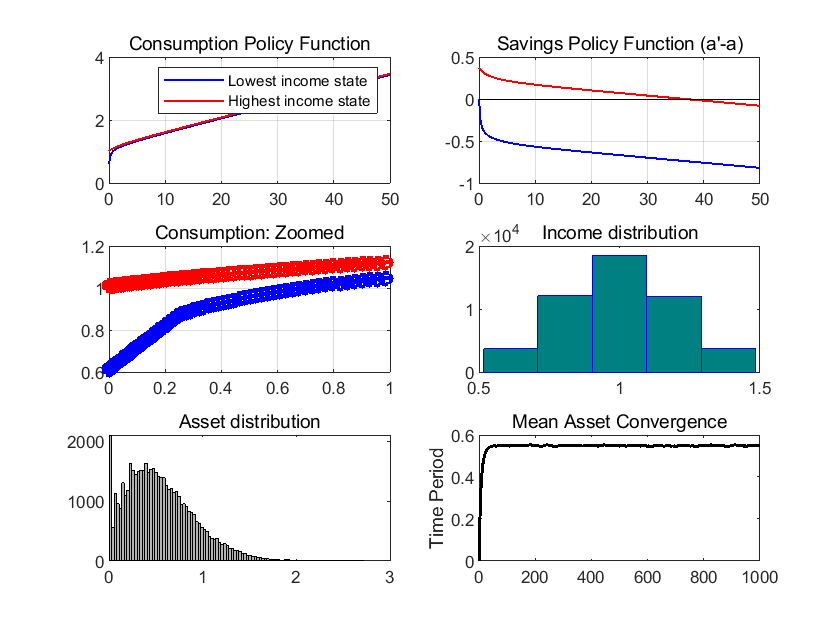

Mean assets (relative to mean income) : 0.55045
Fraction borrowing constrained: 2.96%
10th Percentile: 0.11735
50th Percentile: 0.49915
90th Percentile: 1.0425
99th Percentile: 1.5788


In [9]:
%% Code Cell 6: Make Plots

figure(1);
    
% consumption policy function
subplot(3,2,1);
plot(a_grid,C_next(:,1),'b-',a_grid,C_next(:,y_grid_size),'r-','LineWidth',1);
grid;
xlim([0 a_max]);
title('Consumption Policy Function');
legend('Lowest income state','Highest income state');

% savings policy function
subplot(3,2,2);
plot(a_grid,A_next(:,1)-a_grid,'b-',a_grid,A_next(:,y_grid_size)-a_grid,'r-','LineWidth',1);
hold on;
plot(a_grid,zeros(a_grid_size,1),'k','LineWidth',0.5);
hold off;
grid;
xlim([0 a_max]);
title('Savings Policy Function (a''-a)');
    
% consumption policy function: zoomed in
subplot(3,2,3);
plot(a_grid,C_next(:,1),'b-o',a_grid,C_next(:,y_grid_size),'r-o','LineWidth',2);
grid;
xlim([0 1]);
title('Consumption: Zoomed'); 
 
%income distribution
subplot(3,2,4);
hist(Y_simulation(:,simulation_t_size),y_grid);
h = findobj(gca,'Type','patch');
set(h,'FaceColor',[0 0.5 0.5],'EdgeColor','blue','LineStyle','-');
ylabel('')
title('Income distribution');
    
%asset distribution
subplot(3,2,5);
hist(A_simulation(:,simulation_t_size),100);
h = findobj(gca,'Type','patch');
set(h,'FaceColor',[.7 .7 .7],'EdgeColor','black','LineStyle','-');
ylabel('')
title('Asset distribution');

%convergence check
subplot(3,2,6);
plot([1:simulation_t_size]',mean(A_simulation,1),'k-','LineWidth',1.5);
ylabel('Time Period');
title('Mean Asset Convergence');
    
    
% asset distribution statistics
aysim = A_simulation(:,simulation_t_size) ./ mean(Y_simulation(:,simulation_t_size));
disp(['Mean assets (relative to mean income) : ' num2str(mean(aysim))]);
disp(['Fraction borrowing constrained: ' num2str(sum(aysim==borrow_limit)./simulation_n_size * 100) '%']);
disp(['10th Percentile: ' num2str(quantile(aysim,.1))]);
disp(['50th Percentile: ' num2str(quantile(aysim,.5))]);
disp(['90th Percentile: ' num2str(quantile(aysim,.9))]);
disp(['99th Percentile: ' num2str(quantile(aysim,.99))]);

## Compute MPC

When MPC is very small, an increase in asset almost has no effect on consumption. So, we have:

$$
u'(1+MPC) = \beta (1+r) u'(1+r)
$$


$$
(1+MPC)^{-\gamma} = \beta(1+r) (1+r)^{-\gamma}
$$

Rearrange and get:

$$
MPC = (1+r)[\beta (1+r)]^{-\frac{1}{\gamma}} - 1
$$

In the following code, griddedInterpolant is used instead of interp1, for its object. 

If we use interp1, the code is too long.

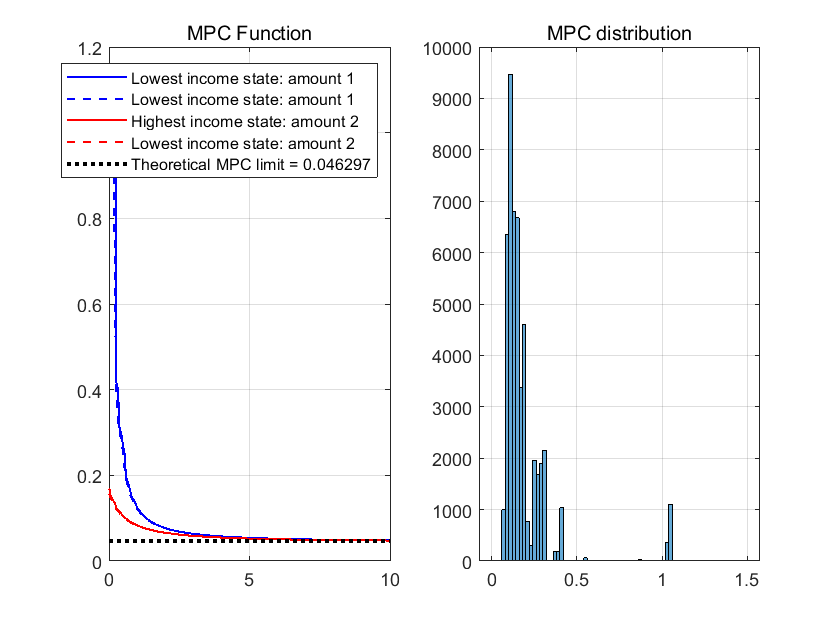

Mean MPC amount 1: 0.19102
Mean MPC amount 2: 0.17411


In [13]:
%% Code Cell 7: Compute MPCs

    
%theoretical mpc lower bound
mpc_limit = (1+r)*((beta*(1+r))^-(1./gamma))-1;
  
for i_y = 1:y_grid_size
    %create interpolating function
    C_interp{i_y} = griddedInterpolant(a_grid,C_current(:,i_y),'linear');
        
    mpc1(:,i_y) = ( C_interp{i_y}(a_grid+mpc_amount1) - C_current(:,i_y) ) ./ mpc_amount1;
    mpc2(:,i_y) = ( C_interp{i_y}(a_grid+mpc_amount2) - C_current(:,i_y) ) ./ mpc_amount2;
        
end

    
figure(2);
    
% mpc functions
subplot(1,2,1);
plot(a_grid,mpc1(:,1),'b-',a_grid,mpc2(:,1),'b--',...
    a_grid,mpc1(:,y_grid_size),'r-',a_grid,mpc2(:,y_grid_size),'r--','LineWidth',1);
hold on;
plot(a_grid,mpc_limit.*ones(size(a_grid)),'k:','LineWidth',2);    
hold off;
grid on;
xlim([0 10]);
title('MPC Function');
legend('Lowest income state: amount 1','Lowest income state: amount 1',...
    'Highest income state: amount 2','Lowest income state: amount 2',...
    ['Theoretical MPC limit = ', num2str(mpc_limit)],'Location','NorthEast');
    
% mpc distribution
mpc1_simulation = zeros(simulation_n_size,1);
mpc2_simulation = zeros(simulation_n_size,1);
for i_y = 1:y_grid_size
    mpc1_simulation(Y_simulation_index(:,simulation_t_size)==i_y) = ...
        ( C_interp{i_y}(A_simulation(Y_simulation_index(:,simulation_t_size)==i_y,simulation_t_size) + mpc_amount1) ...
        - C_interp{i_y}(A_simulation(Y_simulation_index(:,simulation_t_size)==i_y,simulation_t_size)) ) ./ mpc_amount1;
    mpc2_simulation(Y_simulation_index(:,simulation_t_size)==i_y) = ...
        ( C_interp{i_y}(A_simulation(Y_simulation_index(:,simulation_t_size)==i_y,simulation_t_size) + mpc_amount2) ...
        - C_interp{i_y}(A_simulation(Y_simulation_index(:,simulation_t_size)==i_y,simulation_t_size)) ) ./ mpc_amount2;
end
    
subplot(1,2,2);
histogram(mpc1_simulation,[0:0.02:1.5]);
grid on;
h = findobj(gca,'Type','patch');
set(h,'FaceColor',[.7 .7 .7],'EdgeColor','black','LineStyle','-');
ylabel('')
title('MPC distribution');
    
% mpc distribution statistics
disp(['Mean MPC amount 1: ' num2str(mean(mpc1_simulation))]);
disp(['Mean MPC amount 2: ' num2str(mean(mpc2_simulation))]);
    

______________________________________________________________________________________________________________________________________________

# 2. Extend to Stationary Equilibrium: Solve Aiyagari Model

_____________________________________________________________________________________________________________________________________

In the basic model, interest rate and income is exogenous. In stationary equilibiurm of Aiyagari model, these two variables are endogenous.

The process to solve Aiyagari Model is as follows.

<div style="text-align: center;">
    <img src="./Figures/Aiyagari_1.jpg" width="600">
</div>

While in basic optimal consumption with income fluctuation, the process is as follows. 

<div style="text-align: center;">
    <img src="./Figures/Aiyagari_2.jpg" width="480">
</div>

So, in code, the main difference is:    

**1. Loop over capital, to get interest rate and income.**

**2. Interest rate and income is endogenous.**

## Parameters

In [14]:
cd"C:\Users\ading\A_TA_Notes"
pwd

ans = 'C:\Users\ading\A_TA_Notes'

In [15]:
clear all;  % Clears all variables from the workspace
close all;  % Closes all open figure windows
clc;        % Clears the Command Window

In parameters part, compared to basic model, changes are:

    No longer give exogenous interst rate r. Introduce production parameters to calculate r.

    Give one more set iteration parameters for capital K loop. And give initial guess of r and capital K.

In [16]:
%% Code Cell 8: Parameters for Aiyagari

% Households
gamma   = 2;        % risk aversion in consumption utility function 
beta = 0.95;        % How much future utility is worth today

% Production
deprec      = 0.10;
capshare    = 0.4;

% Household income: discretize a normal distribution N(mu,sigma^2)
y_mu    = 1;       % mean of distribution
y_sd    = 0.2;     % standard deviation of income distribution
y_grid_size      = 5;       % number of grid

width = fzero(@(x)discrete_normal(y_grid_size, y_mu, y_sd, x),2);
[temp, y_grid, y_distribution] = discrete_normal(y_grid_size, y_mu, y_sd, width);
y_cum_distribution = cumsum(y_distribution);   % cumulative distribution

% Asset gridss
a_grid_size          = 50;
a_max        = 50; 
borrow_limit  = 0;
a_grid_power   = 0.5; %1 for linear, 0 for L-shaped

a_grid = linspace(0,1,a_grid_size)';
a_grid = a_grid.^(1./a_grid_power);
a_grid = borrow_limit + (a_max - borrow_limit).*a_grid;

% Iteration setting
iteration_max    = 1000;   % maxium iteration
iteration_tolerance    = 1.0e-6; % Tolerance for convergence 


% Simulation setting
simulation_n_size        = 50000;    % number of simulation individuals
simulation_t_size        = 1000;     % number of simulaton periods

% Iteration setting for capital
iteration_max_KL  = 70;
iteration_tolerance_KL      = 1.0e-5;
step_KL     = 0.005;



r_guess      = 1./beta-1 - 0.001; % a bit lower than inverse of discount rate
KLratio_guess = ((r_guess + deprec)/capshare)^(1/(capshare - 1));

Run "Code Cell 2: Local function to facilitate expression". 

In [17]:
%% Code Cell 2: Local function to facilitate expression

% Utility function
if gamma == 1
    u = @(c)log(c);
else    
    u = @(c)(c.^(1-gamma)-1)./(1-gamma);
end    

% Derivative of utility function to consumption
u1 = @(c) c.^(-gamma);               

% When we have u1, how to get consumption.
u1_inverse = @(u) u.^(-1./gamma);

In [18]:
%% Code Cell 3: Initialize value functions and consumption function

C_current = zeros(a_grid_size, y_grid_size);      % current consumption
C_endo    = zeros(a_grid_size, y_grid_size);      % endogenous consumption from Euler equation
C_next    = zeros(a_grid_size, y_grid_size);      % next consumption from interpolation/budget constraint 
A_endo    = zeros(a_grid_size, y_grid_size);      % endogenous asset from budget constraint
A_next    = zeros(a_grid_size, y_grid_size);      % next asset from interpolation/budget constraint

[A_matrix Y_matrix]=ndgrid(a_grid, y_grid);

We need to simulate individuals first, so that we can get aggregate capital.

In [19]:
%% Code Cell 9: Simulate labor efficiency realizations

% Draw random numbers
rng(100);
Y_random = rand(simulation_n_size, simulation_t_size);

% Simulate
Y_simulation_index = zeros(simulation_n_size, simulation_t_size);
    
for i_t = 1 : simulation_t_size
    %income realization: note we vectorize simulations at once because
    %of matlab, in other languages we would loop over individuals
    Y_simulation_index( Y_random(:,i_t) <= y_cum_distribution(1), i_t ) = 1;
    for i_y = 2:y_grid_size
        Y_simulation_index( Y_random(:,i_t) > y_cum_distribution(i_y-1) & Y_random(:,i_t) <= y_cum_distribution(i_y), i_t) = i_y;
    end
end
    
Y_simulation = y_grid(Y_simulation_index);

% initial simulation for asset
A_simulation = zeros(simulation_n_size,simulation_t_size);

## Iteration

In [20]:
%% Iterate over Kl ratio

KLratio = KLratio_guess;

iteration_counter_KL = 0;
iteration_diff_KL = 100; 
while iteration_counter_KL <= iteration_max_KL && abs(iteration_diff_KL)>iteration_tolerance_KL
    iteration_counter_KL = iteration_counter_KL + 1;

    r   = capshare.*KLratio^(capshare-1) - deprec;
    R   = 1+r;
    wage= (1-capshare).* KLratio^capshare;
    % rescale efficiency units of labor so that output = 1.
    % yscale = Y/L
    yscale = (KLratio^-capshare)./(y_grid'*y_distribution);

    C_guess = r.*A_matrix + wage.* yscale.*Y_matrix;
    C_current = C_guess;


    % solve for policy functions with EGP
    % this part is almost same as that in basic model,
    % except that "wage.* yscale.*" before "Y_matrix".

    iteration_counter = 0;        % iteration counting 
    iteration_diff = 100;           % initial difference 
    while iteration_counter <= iteration_max && iteration_diff > iteration_tolerance

        iteration_counter = iteration_counter + 1;
  
        emuc = u1(C_current)*y_distribution;   % expected marginal utility of consumption
        muc1 = beta.*(1+r).*emuc; % new marginal utility from Euler equation
        C_endo = u1_inverse(muc1); % endogenous consumption from marginal utility   

        for i_y = 1:y_grid_size         
        % loop over different y
            A_endo(:,i_y) = (C_endo + A_matrix(:,i_y) - wage.* yscale.* Y_matrix(:,i_y))./(1+r);  
            % endogenous asset from budget constraint 

            A_next(:,i_y) = interp1(A_endo(:,i_y), A_matrix(:,i_y), A_matrix(:,i_y));
            % next asset from interpolation 
        end
    
        A_next = max(A_next, borrow_limit);  % borrowing constraint    
        C_next = (1 + r) .* A_matrix + wage.* yscale.* Y_matrix - A_next; % next consumption from budget constraint

        iteration_diff = max(max(abs(C_current - C_next)));% update new difference
        C_current = C_next; % update current consumption

        % disp(['Iteration no. ' int2str(iteration_counter), ' max con fn diff is ' num2str(iteration_diff)]);
    end                 


    %simulate: start at assets from last interation
    A_simulation(:,1) = A_simulation(:,simulation_t_size);
    
    %create interpolating function
    for i_y = 1:y_grid_size
        savinterp{i_y} = griddedInterpolant(a_grid,A_next(:,i_y),'linear');
    end
    
    %loop over time periods
    for i_t = 1:simulation_t_size        
        % asset choice
        if i_t<simulation_t_size
            for i_y = 1:y_grid_size
                A_simulation(Y_simulation_index(:,i_t)==i_y,i_t+1) = savinterp{i_y}(A_simulation(Y_simulation_index(:,i_t)==i_y,i_t));
            end
        end
    end
    
    %assign actual labor income values;
    labincsim = wage.*yscale.*Y_simulation;

    % mean assets and efficiency units
    Ea  = mean(A_simulation(:,simulation_t_size));
    L   = yscale.*mean(Y_simulation(:,simulation_t_size));
    
    KLrationew = Ea./ L;
    
    iteration_diff_KL = KLrationew./KLratio - 1;
    disp(['Equm iter ' int2str(iteration_counter_KL), ', r  = ',num2str(r), ', KL ratio: ',num2str(KLrationew),' KL diff: ' num2str(iteration_diff_KL*100) '%']);
    
    KLratio = (1-step_KL)*KLratio + step_KL*KLrationew; 
end


Equm iter 1, r  = 0.051632, KL ratio: 3.5309 KL diff: -29.8917%
Equm iter 2, r  = 0.051768, KL ratio: 4.0401 KL diff: -19.6614%
Equm iter 3, r  = 0.051857, KL ratio: 4.5026 KL diff: -10.3761%
Equm iter 4, r  = 0.051905, KL ratio: 4.871 KL diff: -2.9935%
Equm iter 5, r  = 0.051918, KL ratio: 5.1041 KL diff: 1.6649%
Equm iter 6, r  = 0.051911, KL ratio: 5.2025 KL diff: 3.6154%
Equm iter 7, r  = 0.051894, KL ratio: 5.2034 KL diff: 3.6154%
Equm iter 8, r  = 0.051878, KL ratio: 5.1555 KL diff: 2.6434%
Equm iter 9, r  = 0.051866, KL ratio: 5.0972 KL diff: 1.4694%
Equm iter 10, r  = 0.051859, KL ratio: 5.0498 KL diff: 0.51677%
Equm iter 11, r  = 0.051857, KL ratio: 5.0201 KL diff: -0.077136%
Equm iter 12, r  = 0.051857, KL ratio: 5.0067 KL diff: -0.34339%
Equm iter 13, r  = 0.051859, KL ratio: 5.0046 KL diff: -0.38225%
Equm iter 14, r  = 0.05186, KL ratio: 5.0086 KL diff: -0.30064%
Equm iter 15, r  = 0.051862, KL ratio: 5.0145 KL diff: -0.18152%
Equm iter 16, r  = 0.051862, KL ratio: 5.0198 K

## Graph

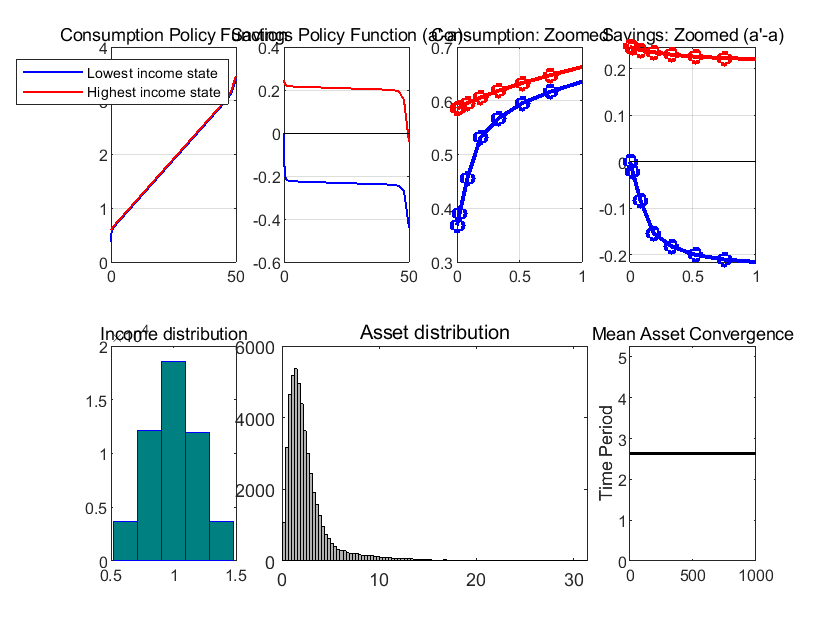

Mean assets: 2.634
Fraction borrowing constrained: 0.038%
10th Percentile: 0.68697
50th Percentile: 1.9261
90th Percentile: 5.0767
99th Percentile: 13.5927


In [21]:
    figure(1);
    
    % consumption policy function
    subplot(2,4,1);
    plot(a_grid,C_next(:,1),'b-',a_grid,C_next(:,y_grid_size),'r-','LineWidth',1);
    grid;
    xlim([0 a_max]);
    title('Consumption Policy Function');
    legend('Lowest income state','Highest income state');

    % savings policy function
    subplot(2,4,2);
    plot(a_grid,A_next(:,1)-a_grid,'b-',a_grid,A_next(:,y_grid_size)-a_grid,'r-','LineWidth',1);
    hold on;
    plot(a_grid,zeros(a_grid_size,1),'k','LineWidth',0.5);
    hold off;
    grid;
    xlim([0 a_max]);
    title('Savings Policy Function (a''-a)');
    
    % consumption policy function: zoomed in
    subplot(2,4,3);
    plot(a_grid,C_next(:,1),'b-o',a_grid,C_next(:,y_grid_size),'r-o','LineWidth',2);
    grid;
    xlim([0 1]);
    title('Consumption: Zoomed');
    
     % savings policy function: zoomed in
    subplot(2,4,4);
    plot(a_grid,A_next(:,1)-a_grid,'b-o',a_grid,A_next(:,y_grid_size)-a_grid,'r-o','LineWidth',2);
    hold on;
    plot(a_grid,zeros(a_grid_size,1),'k','LineWidth',0.5);
    hold off;
    grid;
    xlim([0 1]);
    title('Savings: Zoomed (a''-a)');
    
    
    %income distribution
    subplot(2,4,5);
    hist(Y_simulation(:,simulation_t_size),y_grid);
    h = findobj(gca,'Type','patch');
    set(h,'FaceColor',[0 0.5 0.5],'EdgeColor','blue','LineStyle','-');
    ylabel('')
    title('Income distribution');
    
    %asset distribution
    subplot(2,4,6:7);
    hist(A_simulation(:,simulation_t_size),100);
    h = findobj(gca,'Type','patch');
    set(h,'FaceColor',[.7 .7 .7],'EdgeColor','black','LineStyle','-');
    ylabel('')
    title('Asset distribution');

    %convergence check
    subplot(2,4,8);
    plot([1:simulation_t_size]',mean(A_simulation,1),'k-','LineWidth',1.5);
    ylim([0 2*Ea]);
    ylabel('Time Period');
    title('Mean Asset Convergence');
    
    
   % asset distribution statistics
    aysim = A_simulation(:,simulation_t_size) ./ mean(Y_simulation(:,simulation_t_size));
    disp(['Mean assets: ' num2str(mean(aysim))]);
    disp(['Fraction borrowing constrained: ' num2str(sum(aysim==borrow_limit)./simulation_n_size * 100) '%']);
    disp(['10th Percentile: ' num2str(quantile(aysim,.1))]);
    disp(['50th Percentile: ' num2str(quantile(aysim,.5))]);
    disp(['90th Percentile: ' num2str(quantile(aysim,.9))]);
    disp(['99th Percentile: ' num2str(quantile(aysim,.99))]);